# House Price ML - Statistik, Visualisasi, dan Review Model

Notebook ini memvisualisasikan proses end-to-end secara jelas:
1. Data loading dan data quality check
2. Statistik deskriptif (numerik + kategorikal)
3. Visualisasi distribusi target dan missing values
4. Training 3 model regresi
5. Evaluasi metrik MAE, RMSE, R2 (train & test)
6. Visualisasi performa model dan residual
7. Feature importance / koefisien
8. Simpan artifact model + metrics
9. Prediksi data baru


## 0) Setup Root Project
Jalankan notebook ini dari folder `house-price-ml` atau `house-price-ml/notebooks`.

In [18]:
from pathlib import Path
import os
import sys

if (Path.cwd() / "src").exists():
    ROOT = Path.cwd()
elif (Path.cwd().parent / "src").exists():
    ROOT = Path.cwd().parent
else:
    raise RuntimeError("Folder src tidak ditemukan. Jalankan notebook dari root project atau folder notebooks.")

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")


Project root: /Users/ramadhanial-qadri/Documents/My_File/Machine Learning/Basic/House Prediction/house-price-ml


## 1) Import Library

In [19]:
# Install dependencies into the active Jupyter kernel
%pip install -q joblib numpy pandas matplotlib seaborn scikit-learn

import json
from datetime import datetime, timezone

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

from src.data import load_data, split_data, build_preprocessor
from src.utils import evaluate_model

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## 2) Konfigurasi Eksperimen
Ganti `TARGET_COL` jika nama target di dataset berbeda.

In [20]:
DATA_PATH = ROOT / "data/raw/houses.csv"
TARGET_COL = "Price (in rupees)"  # TODO: ganti jika target kamu berbeda
RANDOM_STATE = 42
TEST_SIZE = 0.2

MODEL_PATH = ROOT / "models/model.joblib"
METRICS_PATH = ROOT / "reports/metrics.json"
PREDICTION_OUTPUT_PATH = ROOT / "reports/predictions_from_notebook.csv"

print(f"Data path : {DATA_PATH}")
print(f"Target    : {TARGET_COL}")
print(f"Test size : {TEST_SIZE}")


Data path : /Users/ramadhanial-qadri/Documents/My_File/Machine Learning/Basic/House Prediction/house-price-ml/data/raw/houses.csv
Target    : Price (in rupees)
Test size : 0.2


## 3) Load Data dan Data Quality Check

In [21]:
df = load_data(DATA_PATH)

if TARGET_COL not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COL}' tidak ditemukan. TODO: ubah TARGET_COL di cell konfigurasi."
    )

print(f"Shape dataset: {df.shape[0]:,} rows x {df.shape[1]:,} columns")

display(df.head(3))

dtype_counts = df.dtypes.astype(str).value_counts().rename_axis("dtype").reset_index(name="count")
display(dtype_counts)

missing_df = (df.isna().sum().to_frame("missing_count"))
missing_df["missing_pct"] = (missing_df["missing_count"] / len(df) * 100).round(2)
missing_df = missing_df.sort_values("missing_pct", ascending=False)
display(missing_df.head(15))


Shape dataset: 187,531 rows x 21 columns


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN


,dtype,count
0,object,17
1,float64,3
2,int64,1


,missing_count,missing_pct
Plot Area,187531,100.00
Dimensions,187531,100.00
Society,109678,58.49
Super Area,107685,57.42
Car Parking,103357,55.11
overlooking,81436,43.43
Carpet Area,80673,43.02
facing,70233,37.45
Ownership,65517,34.94
Balcony,48935,26.09


## 4) Statistik Deskriptif

In [22]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Jumlah kolom numerik    : {len(numeric_cols)}")
print(f"Jumlah kolom kategorikal: {len(categorical_cols)}")

if numeric_cols:
    print("\nStatistik kolom numerik:")
    display(df[numeric_cols].describe().T)

if categorical_cols:
    cat_stats = pd.DataFrame({
        "n_unique": df[categorical_cols].nunique(dropna=True),
        "top_value": df[categorical_cols].mode(dropna=True).iloc[0],
        "top_freq": df[categorical_cols].apply(lambda s: s.value_counts(dropna=True).iloc[0] if s.value_counts(dropna=True).shape[0] > 0 else np.nan),
        "missing_pct": (df[categorical_cols].isna().mean() * 100).round(2),
    }).sort_values("n_unique", ascending=False)

    print("\nStatistik kolom kategorikal:")
    display(cat_stats.head(15))


Jumlah kolom numerik    : 4
Jumlah kolom kategorikal: 17

Statistik kolom numerik:


,count,mean,std,min,25%,50%,75%,max
Index,187531.0,93765.000000,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Price (in rupees),169866.0,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
Dimensions,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Plot Area,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Statistik kolom kategorikal:


,n_unique,top_value,top_freq,missing_pct
Description,65634,Multistorey apartment is available for sale. I...,2732,1.61
Title,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,0.00
Society,10376,Hamdam Apartment,1648,58.49
Super Area,2976,1100 sqft,2599,57.42
Carpet Area,2758,1000 sqft,5285,43.02
Amount(in rupees),1561,Call for Price,9684,0.00
Floor,947,2 out of 4,12433,3.77
Car Parking,229,1 Covered,38754,55.11
location,81,new-delhi,27599,0.00
overlooking,19,Main Road,32193,43.43


## 5) Visualisasi Missing Values

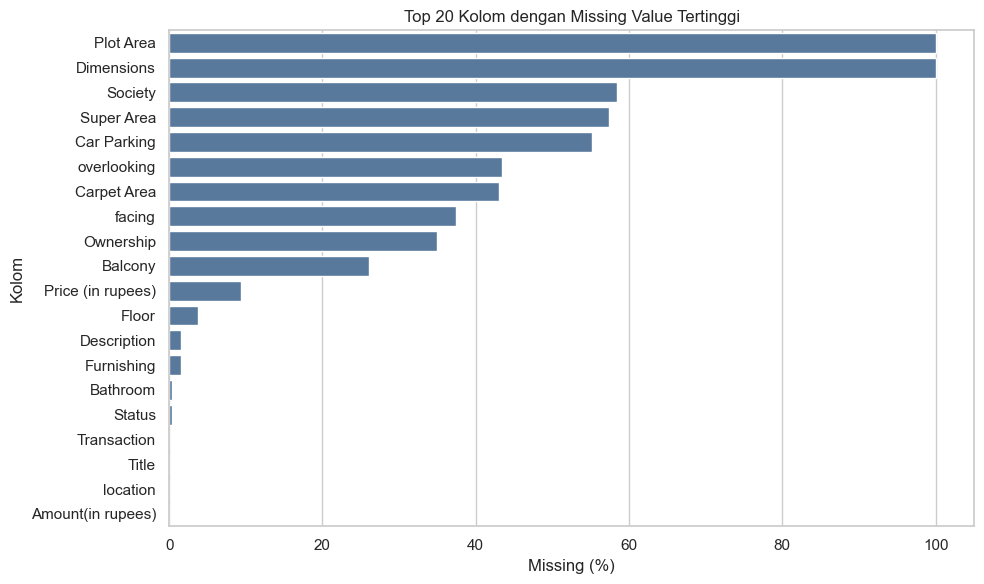

In [23]:
top_missing = missing_df.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_missing.reset_index(), x="missing_pct", y="index", color="#4C78A8")
plt.title("Top 20 Kolom dengan Missing Value Tertinggi")
plt.xlabel("Missing (%)")
plt.ylabel("Kolom")
plt.tight_layout()
plt.show()


## 6) Analisis Target (Sebelum Training)

Valid target rows  : 169,866
Invalid/NaN target : 17,665


,target_stats
count,1.698660e+05
mean,7.583772e+03
std,2.724171e+04
min,0.000000e+00
25%,4.297000e+03
50%,6.034000e+03
75%,9.450000e+03
max,6.700000e+06


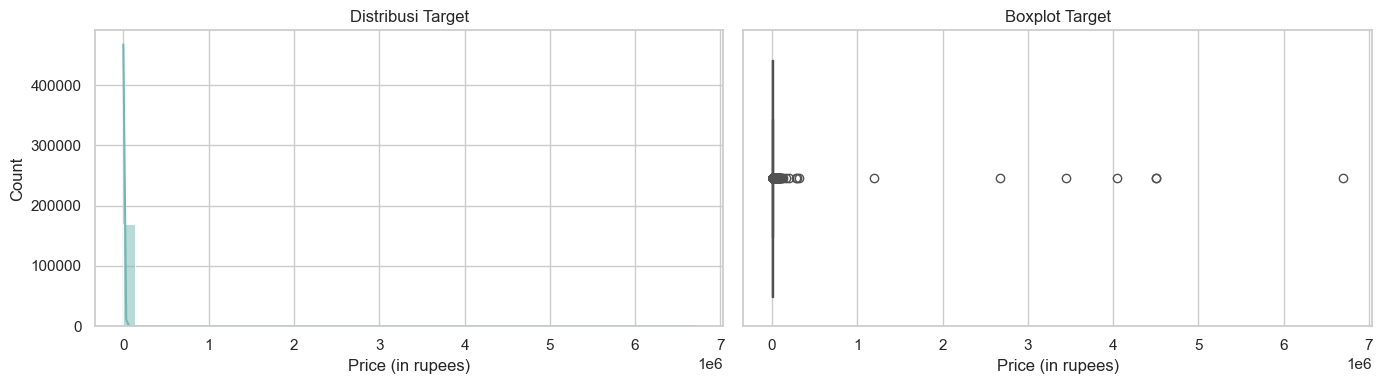

In [24]:
target_raw = df[TARGET_COL]
if pd.api.types.is_numeric_dtype(target_raw):
    target_num = pd.to_numeric(target_raw, errors="coerce")
else:
    target_num = pd.to_numeric(
        target_raw.astype(str).str.strip().str.replace(",", "", regex=False).str.replace(r"[^\d.\-]", "", regex=True),
        errors="coerce",
    )

valid_target = target_num.dropna()
invalid_target_count = target_num.isna().sum()

print(f"Valid target rows  : {len(valid_target):,}")
print(f"Invalid/NaN target : {invalid_target_count:,}")
display(valid_target.describe().to_frame("target_stats"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(valid_target, bins=50, kde=True, ax=axes[0], color="#72B7B2")
axes[0].set_title("Distribusi Target")
axes[0].set_xlabel(TARGET_COL)

sns.boxplot(x=valid_target, ax=axes[1], color="#F58518")
axes[1].set_title("Boxplot Target")
axes[1].set_xlabel(TARGET_COL)

plt.tight_layout()
plt.show()


## 7) Split Data dan Preprocessing

In [25]:
X_train, X_test, y_train, y_test = split_data(
    df,
    target_col=TARGET_COL,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

preprocessor, numeric_features, categorical_features = build_preprocessor(X_train)
feature_columns = numeric_features + categorical_features

used_rows = len(X_train) + len(X_test)
dropped_rows = len(df) - used_rows

print(f"Rows digunakan              : {used_rows:,}")
print(f"Rows dibuang (target invalid): {dropped_rows:,}")
print(f"Train size                   : {len(X_train):,}")
print(f"Test size                    : {len(X_test):,}")
print(f"Numeric features             : {len(numeric_features)}")
print(f"Categorical features         : {len(categorical_features)}")
display(pd.DataFrame({"feature": feature_columns}).head(20))


[WARN] Dropping 17665 row(s) because target 'Price (in rupees)' is missing/non-numeric.
[WARN] Dropping 2 all-missing feature(s): Dimensions, Plot Area
Rows digunakan              : 169,866
Rows dibuang (target invalid): 17,665
Train size                   : 135,892
Test size                    : 33,974
Numeric features             : 1
Categorical features         : 17


,feature
0,Index
1,Title
2,Description
3,Amount(in rupees)
4,location
5,Carpet Area
6,Status
7,Floor
8,Transaction
9,Furnishing


## 8) Training Model Kandidat

In [26]:
rf = RandomForestRegressor(
    n_estimators=250,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    min_samples_leaf=5,
    max_features="sqrt",
)

candidates = {
    "dummy_median": DummyRegressor(strategy="median"),
    "linear_regression": LinearRegression(),
    "random_forest": rf,
    "random_forest_log_target": TransformedTargetRegressor(
        regressor=clone(rf),
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    ),
    "gradient_boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        subsample=0.8,
    ),
}

results = {}
trained_pipelines = {}
test_predictions = {}

for model_name, model in candidates.items():
    pipe = Pipeline(steps=[("preprocess", clone(preprocessor)), ("model", model)])
    pipe.fit(X_train, y_train)

    metrics = evaluate_model(pipe, X_train, y_train, X_test, y_test)
    results[model_name] = metrics
    trained_pipelines[model_name] = pipe
    test_predictions[model_name] = pipe.predict(X_test)

    print(
        f"{model_name:<24} | test_rmse={metrics['test']['rmse']:.4f} | test_mae={metrics['test']['mae']:.4f} | test_r2={metrics['test']['r2']:.4f}"
    )


dummy_median             | test_rmse=44519.8364 | test_mae=3495.3570 | test_r2=-0.0016
linear_regression        | test_rmse=44722.7544 | test_mae=1020.1974 | test_r2=-0.0108
random_forest            | test_rmse=44349.5765 | test_mae=2383.5041 | test_r2=0.0060
random_forest_log_target | test_rmse=44387.9750 | test_mae=2328.4708 | test_r2=0.0043
gradient_boosting        | test_rmse=44857.5641 | test_mae=2555.2329 | test_r2=-0.0169


## 9) Tabel Metrik dan Ranking Model

In [27]:
rows = []
for model_name, split_metrics in results.items():
    for split_name, metric_values in split_metrics.items():
        rows.append(
            {
                "model": model_name,
                "split": split_name,
                "mae": metric_values["mae"],
                "rmse": metric_values["rmse"],
                "r2": metric_values["r2"],
            }
        )

metrics_df = pd.DataFrame(rows)
display(metrics_df.sort_values(["split", "rmse"], ascending=[True, True]))

test_ranking = metrics_df[metrics_df["split"] == "test"].sort_values("rmse").reset_index(drop=True)
display(test_ranking)

best_model_name = test_ranking.loc[0, "model"]
best_pipeline = trained_pipelines[best_model_name]
print(f"Best model by test RMSE: {best_model_name}")


,model,split,mae,rmse,r2
5,random_forest,test,2383.504101,44349.576497,0.005998
7,random_forest_log_target,test,2328.470807,44387.974953,0.004276
1,dummy_median,test,3495.356979,44519.836433,-0.001648
3,linear_regression,test,1020.197363,44722.754422,-0.010800
9,gradient_boosting,test,2555.232912,44857.564125,-0.016903
2,linear_regression,train,14.048225,64.677744,0.999990
8,gradient_boosting,train,2137.081730,3287.707869,0.975032
4,random_forest,train,2102.558405,20429.295274,0.035939
6,random_forest_log_target,train,2035.732450,20575.432054,0.022097
0,dummy_median,train,3190.573831,20859.575366,-0.005099


,model,split,mae,rmse,r2
0,random_forest,test,2383.504101,44349.576497,0.005998
1,random_forest_log_target,test,2328.470807,44387.974953,0.004276
2,dummy_median,test,3495.356979,44519.836433,-0.001648
3,linear_regression,test,1020.197363,44722.754422,-0.010800
4,gradient_boosting,test,2555.232912,44857.564125,-0.016903


Best model by test RMSE: random_forest


## 10) Visualisasi Perbandingan Model (Test Set)

/var/folders/bh/4bs_s9c141572hn76frt9hk40000gn/T/ipykernel_36940/2219291571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=test_ranking, x="model", y="mae", ax=axes[0], palette="Blues_d")
/var/folders/bh/4bs_s9c141572hn76frt9hk40000gn/T/ipykernel_36940/2219291571.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=test_ranking, x="model", y="rmse", ax=axes[1], palette="Greens_d")
/var/folders/bh/4bs_s9c141572hn76frt9hk40000gn/T/ipykernel_36940/2219291571.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=test_ranking, x

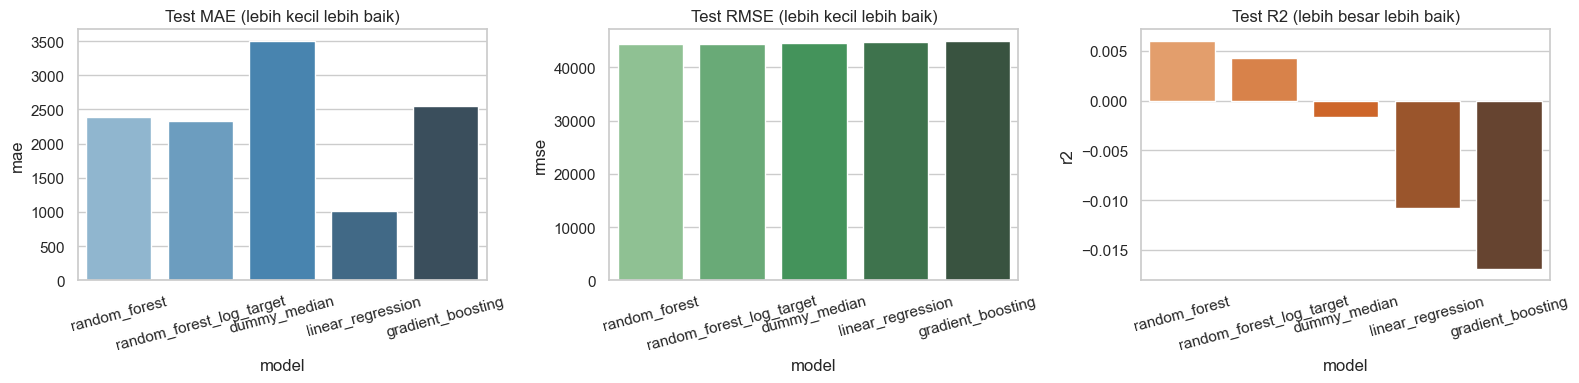

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=test_ranking, x="model", y="mae", ax=axes[0], palette="Blues_d")
axes[0].set_title("Test MAE (lebih kecil lebih baik)")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=test_ranking, x="model", y="rmse", ax=axes[1], palette="Greens_d")
axes[1].set_title("Test RMSE (lebih kecil lebih baik)")
axes[1].tick_params(axis="x", rotation=15)

sns.barplot(data=test_ranking, x="model", y="r2", ax=axes[2], palette="Oranges_d")
axes[2].set_title("Test R2 (lebih besar lebih baik)")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


## 11) Plot Actual vs Predicted dan Residual (Best Model)

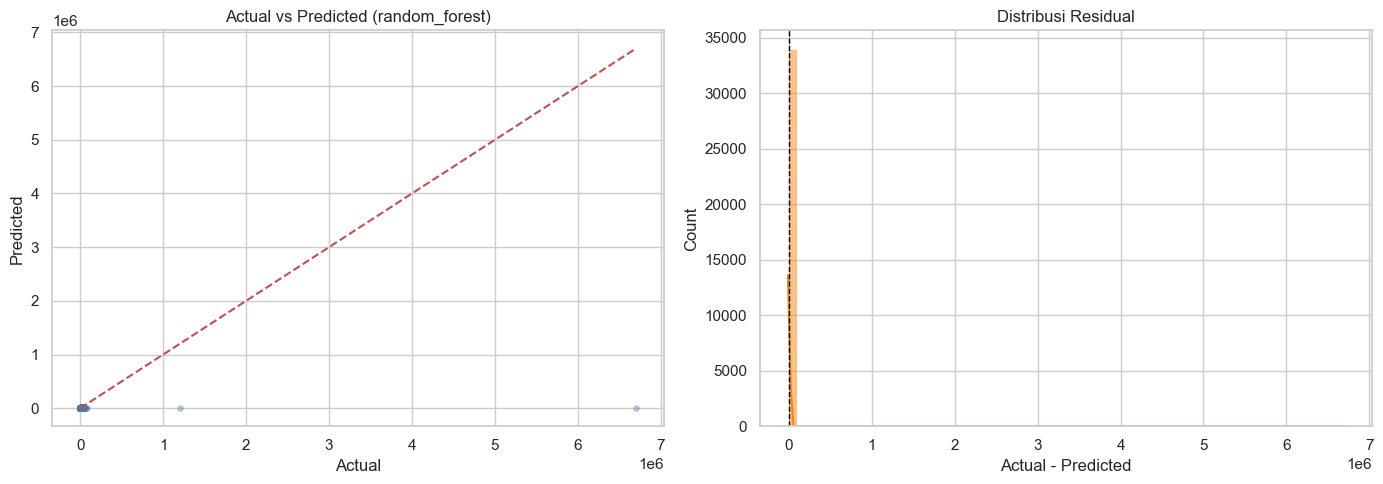

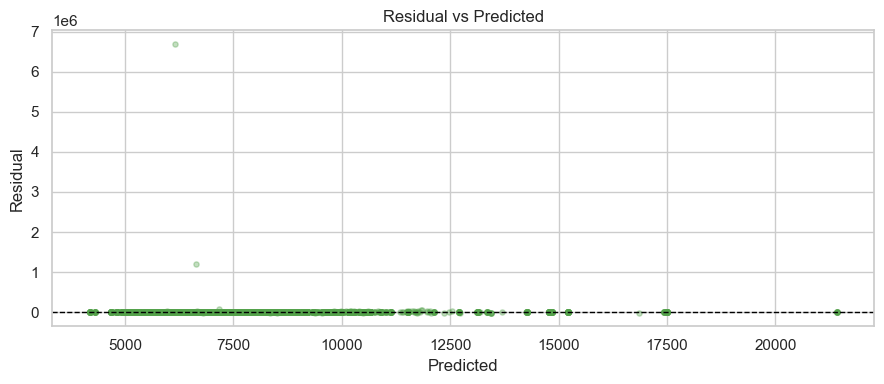

In [29]:
y_true = pd.Series(y_test).reset_index(drop=True)
y_pred = pd.Series(test_predictions[best_model_name]).reset_index(drop=True)
residuals = y_true - y_pred

rng = np.random.RandomState(RANDOM_STATE)
sample_n = min(5000, len(y_true))
sample_idx = rng.choice(len(y_true), size=sample_n, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_true.iloc[sample_idx], y_pred.iloc[sample_idx], alpha=0.35, s=14, color="#4C78A8")
min_val = float(min(y_true.min(), y_pred.min()))
max_val = float(max(y_true.max(), y_pred.max()))
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5)
axes[0].set_title(f"Actual vs Predicted ({best_model_name})")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

sns.histplot(residuals, bins=60, kde=True, ax=axes[1], color="#F58518")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Distribusi Residual")
axes[1].set_xlabel("Actual - Predicted")

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.scatter(y_pred.iloc[sample_idx], residuals.iloc[sample_idx], alpha=0.35, s=14, color="#54A24B")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Residual vs Predicted")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()


## 12) Korelasi Fitur Numerik (Jika Ada > 1 Kolom)

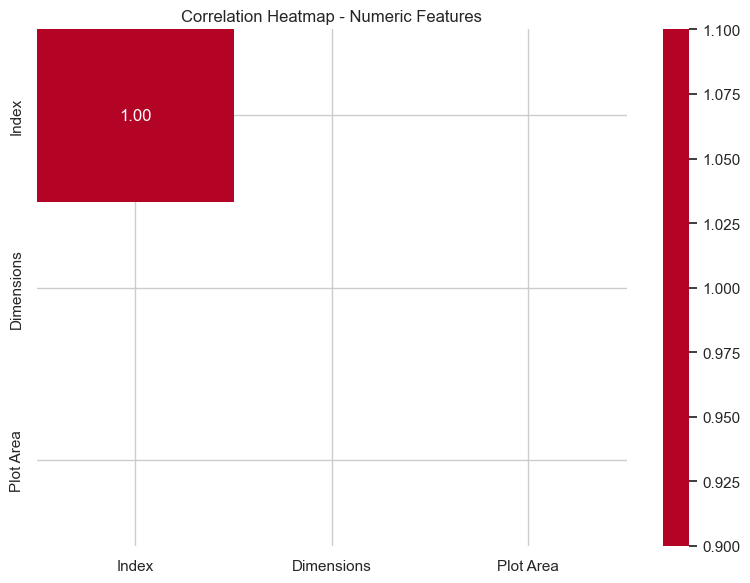

In [30]:
numeric_for_corr = df[numeric_cols].copy()
if TARGET_COL in numeric_for_corr.columns:
    numeric_for_corr = numeric_for_corr.drop(columns=[TARGET_COL])

if numeric_for_corr.shape[1] > 1:
    corr = numeric_for_corr.corr(numeric_only=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
    plt.title("Correlation Heatmap - Numeric Features")
    plt.tight_layout()
    plt.show()
else:
    print("Kolom numerik < 2, heatmap korelasi tidak informatif untuk dataset ini.")


## 13) Feature Importance / Koefisien (Best Model)

,feature,importance
75711,cat__location_mumbai,0.039037
75740,cat__location_udaipur,0.035686
78138,cat__Carpet Area_970 sqft,0.027509
78075,cat__Carpet Area_920 sqft,0.025830
75718,cat__location_new-delhi,0.025451
0,num__Index,0.022564
75031,cat__Amount(in rupees)_5.76 Cr,0.022331
87739,cat__Car Parking_1 Covered,0.019269
15100,cat__Title_3 BHK Ready to Occupy Flat for sale...,0.015790
78517,cat__Floor_2 out of 9,0.014804


/var/folders/bh/4bs_s9c141572hn76frt9hk40000gn/T/ipykernel_36940/3499595613.py:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


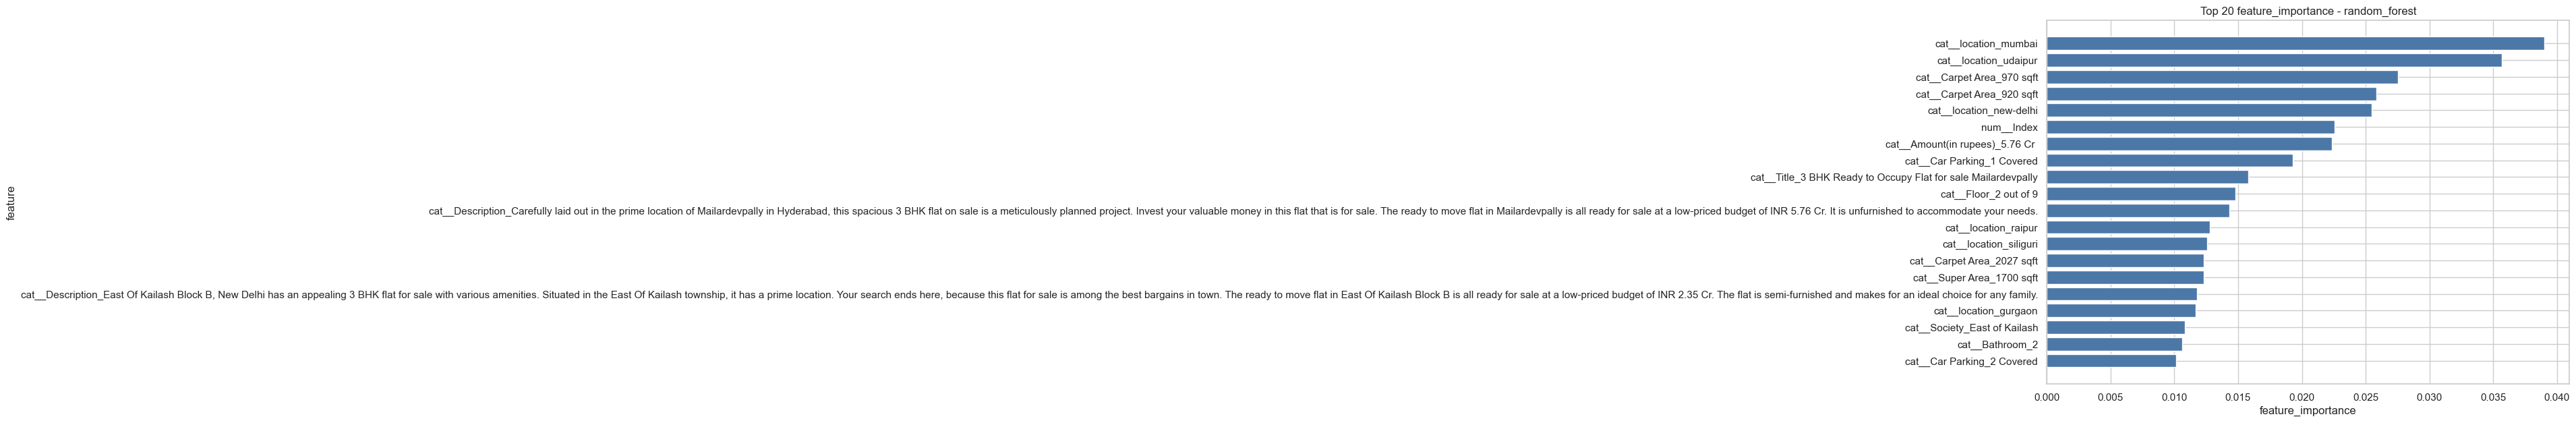

In [31]:
fitted_preprocess = best_pipeline.named_steps["preprocess"]
final_model = best_pipeline.named_steps["model"]

if hasattr(fitted_preprocess, "named_steps") and "columns" in fitted_preprocess.named_steps:
    feature_extractor = fitted_preprocess.named_steps["columns"]
else:
    feature_extractor = fitted_preprocess

feature_names = list(feature_extractor.get_feature_names_out())

importance_kind = None
if hasattr(final_model, "feature_importances_"):
    importance_values = np.asarray(final_model.feature_importances_).ravel()
    importance_kind = "feature_importance"
elif hasattr(final_model, "coef_"):
    importance_values = np.abs(np.asarray(final_model.coef_).ravel())
    importance_kind = "abs_coefficient"
elif hasattr(final_model, "regressor_") and hasattr(final_model.regressor_, "feature_importances_"):
    importance_values = np.asarray(final_model.regressor_.feature_importances_).ravel()
    importance_kind = "feature_importance"
elif hasattr(final_model, "regressor_") and hasattr(final_model.regressor_, "coef_"):
    importance_values = np.abs(np.asarray(final_model.regressor_.coef_).ravel())
    importance_kind = "abs_coefficient"
else:
    importance_values = None

if importance_values is None:
    print("Model tidak menyediakan feature importance/coef.")
else:
    size = min(len(feature_names), len(importance_values))
    importance_df = pd.DataFrame({
        "feature": feature_names[:size],
        "importance": importance_values[:size],
    }).sort_values("importance", ascending=False)

    display(importance_df.head(20))

    top_imp = importance_df.head(20).sort_values("importance", ascending=True)
    plt.figure(figsize=(10, 7))
    plt.barh(top_imp["feature"], top_imp["importance"], color="#4C78A8")
    plt.title(f"Top 20 {importance_kind} - {best_model_name}")
    plt.xlabel(importance_kind)
    plt.ylabel("feature")
    plt.tight_layout()
    plt.show()


## 14) Simpan Model dan Metrics

In [32]:
best_rmse = float(results[best_model_name]["test"]["rmse"])

model_artifact = {
    "pipeline": best_pipeline,
    "feature_columns": feature_columns,
    "target_column": TARGET_COL,
    "best_model_name": best_model_name,
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
}

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model_artifact, MODEL_PATH)

metrics_payload = {
    "data_path": str(DATA_PATH.relative_to(ROOT)),
    "target_column": TARGET_COL,
    "n_rows": int(len(df)),
    "n_rows_used": int(used_rows),
    "n_rows_dropped_target_invalid": int(dropped_rows),
    "n_features": int(len(feature_columns)),
    "feature_columns": feature_columns,
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "models": results,
    "best_model": {
        "name": best_model_name,
        "selection_metric": "test_rmse",
        "value": best_rmse,
        "metrics": results[best_model_name],
    },
}

with METRICS_PATH.open("w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2, ensure_ascii=False)

print(f"Saved model  : {MODEL_PATH}")
print(f"Saved metrics: {METRICS_PATH}")


Saved model  : /Users/ramadhanial-qadri/Documents/My_File/Machine Learning/Basic/House Prediction/house-price-ml/models/model.joblib
Saved metrics: /Users/ramadhanial-qadri/Documents/My_File/Machine Learning/Basic/House Prediction/house-price-ml/reports/metrics.json


## 15) Review Hasil Machine Learning

In [33]:
best_train = results[best_model_name]["train"]
best_test = results[best_model_name]["test"]
rmse_gap = float(best_test["rmse"] - best_train["rmse"])
mae_gap = float(best_test["mae"] - best_train["mae"])

baseline_name = "dummy_median" if "dummy_median" in results else None
baseline_test_rmse = float(results[baseline_name]["test"]["rmse"]) if baseline_name else np.nan
baseline_rmse_improvement_pct = float((baseline_test_rmse - best_test["rmse"]) / baseline_test_rmse * 100) if baseline_name else np.nan

print("=== REVIEW RINGKAS ===")
print(f"Best model   : {best_model_name}")
print(f"Train MAE/RMSE/R2: {best_train['mae']:.4f} / {best_train['rmse']:.4f} / {best_train['r2']:.4f}")
print(f"Test  MAE/RMSE/R2: {best_test['mae']:.4f} / {best_test['rmse']:.4f} / {best_test['r2']:.4f}")
print(f"MAE gap      : {mae_gap:.4f}")
print(f"RMSE gap     : {rmse_gap:.4f}")
print(f"Rows dropped : {dropped_rows:,}")
if baseline_name:
    print(f"Baseline RMSE ({baseline_name}): {baseline_test_rmse:.4f}")
    print(f"Improvement vs baseline RMSE  : {baseline_rmse_improvement_pct:.2f}%")

review_notes = []
if best_test['r2'] < 0:
    review_notes.append("R2 test negatif, model belum menangkap pola dengan baik pada data uji.")
elif best_test['r2'] < 0.2:
    review_notes.append("R2 test masih rendah, model masih tahap baseline.")
else:
    review_notes.append("R2 test cukup baik untuk baseline.")

if rmse_gap > 0 and (rmse_gap / max(best_test['rmse'], 1e-9)) > 0.30:
    review_notes.append("Gap train-test besar, indikasi overfitting atau distribusi train-test berbeda.")

if baseline_name and baseline_rmse_improvement_pct < 5:
    review_notes.append("Kenaikan terhadap baseline kecil; perlu feature engineering tambahan.")

if dropped_rows > 0:
    review_notes.append("Target invalid cukup banyak; data cleaning target penting untuk meningkatkan performa.")

print("\nCatatan review:")
for i, note in enumerate(review_notes, 1):
    print(f"{i}. {note}")

print("\nSaran peningkatan:")
print("1. Tambah fitur numerik terstruktur (area/floor/parking) dan kurangi ketergantungan ke teks mentah.")
print("2. Coba validasi silang (cross-validation) untuk cek kestabilan metrik.")
print("3. Uji model tree-boosting lain + tuning hyperparameter berbasis RMSE.")


=== REVIEW RINGKAS ===
Best model   : random_forest
Train MAE/RMSE/R2: 2102.5584 / 20429.2953 / 0.0359
Test  MAE/RMSE/R2: 2383.5041 / 44349.5765 / 0.0060
MAE gap      : 280.9457
RMSE gap     : 23920.2812
Rows dropped : 17,665
Baseline RMSE (dummy_median): 44519.8364
Improvement vs baseline RMSE  : 0.38%

Catatan review:
1. R2 test masih rendah, model masih tahap baseline.
2. Gap train-test besar, indikasi overfitting atau distribusi train-test berbeda.
3. Kenaikan terhadap baseline kecil; perlu feature engineering tambahan.
4. Target invalid cukup banyak; data cleaning target penting untuk meningkatkan performa.

Saran peningkatan:
1. Tambah fitur numerik terstruktur (area/floor/parking) dan kurangi ketergantungan ke teks mentah.
2. Coba validasi silang (cross-validation) untuk cek kestabilan metrik.
3. Uji model tree-boosting lain + tuning hyperparameter berbasis RMSE.


## 16) Prediksi Data Baru

[INFO] new_data.csv tidak ditemukan, fallback ke _sample_200.csv
Prediction input : /Users/ramadhanial-qadri/Documents/My_File/Machine Learning/Basic/House Prediction/house-price-ml/data/raw/_sample_200.csv
Prediction output: /Users/ramadhanial-qadri/Documents/My_File/Machine Learning/Basic/House Prediction/house-price-ml/reports/predictions_from_notebook.csv


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area,prediction
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2.0,NaN,NaN,NaN,NaN,NaN,7592.872032
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN,8525.430473
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN,8289.181311
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1.0,NaN,NaN,NaN,NaN,NaN,6974.599032
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN,9432.328370


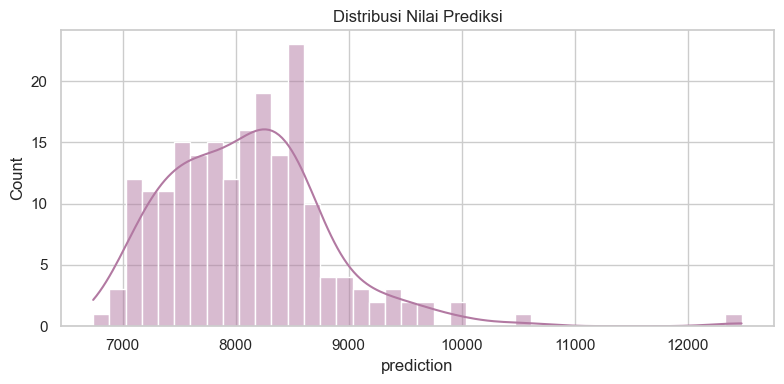

In [34]:
NEW_DATA_PATH = ROOT / "data/raw/new_data.csv"
if NEW_DATA_PATH.exists():
    prediction_input_path = NEW_DATA_PATH
else:
    prediction_input_path = ROOT / "data/raw/_sample_200.csv"
    print("[INFO] new_data.csv tidak ditemukan, fallback ke _sample_200.csv")

pred_input_df = pd.read_csv(prediction_input_path)
missing_cols = [c for c in feature_columns if c not in pred_input_df.columns]
if missing_cols:
    raise ValueError(
        f"Input prediksi kurang {len(missing_cols)} kolom fitur training. Contoh: {missing_cols[:10]}"
    )

pred_X = pred_input_df[feature_columns].copy()
pred_vals = best_pipeline.predict(pred_X)

pred_output_df = pred_input_df.copy()
pred_output_df["prediction"] = pred_vals

PREDICTION_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
pred_output_df.to_csv(PREDICTION_OUTPUT_PATH, index=False)

print(f"Prediction input : {prediction_input_path}")
print(f"Prediction output: {PREDICTION_OUTPUT_PATH}")
display(pred_output_df.head(5))

plt.figure(figsize=(8, 4))
sns.histplot(pred_output_df["prediction"], bins=40, kde=True, color="#B279A2")
plt.title("Distribusi Nilai Prediksi")
plt.xlabel("prediction")
plt.tight_layout()
plt.show()
